<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Custom embedddings con Gensim



### Objetivo
El objetivo es utilizar documentos / corpus para crear embeddings de palabras basado en ese contexto. Se utilizará canciones de bandas para generar los embeddings, es decir, que los vectores tendrán la forma en función de como esa banda haya utilizado las palabras en sus canciones.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import multiprocessing
try:
  from gensim.models import Word2Vec
except:
  !pip install gensim
  from gensim.models import Word2Vec

### Datos
Utilizaremos como dataset canciones de bandas de habla inglesa.

In [2]:
# Descargar la carpeta de dataset
import os
import platform
if os.access('./songs_dataset', os.F_OK) is False:
    if os.access('songs_dataset.zip', os.F_OK) is False:
        if platform.system() == 'Windows':
            !curl https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip -o songs_dataset.zip
        else:
            !wget songs_dataset.zip https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
    !unzip -q songs_dataset.zip
else:
    print("El dataset ya se encuentra descargado")

--2026-05-21 21:20:06--  http://songs_dataset.zip/
Resolving songs_dataset.zip (songs_dataset.zip)... failed: Name or service not known.
wget: unable to resolve host address ‘songs_dataset.zip’
--2026-05-21 21:20:06--  https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip [following]
--2026-05-21 21:20:06--  https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.

In [3]:
# Posibles bandas
os.listdir("./songs_dataset/")

['ludacris.txt',
 'bob-marley.txt',
 'lin-manuel-miranda.txt',
 'nicki-minaj.txt',
 'prince.txt',
 'alicia-keys.txt',
 'amy-winehouse.txt',
 'drake.txt',
 'disney.txt',
 'cake.txt',
 'johnny-cash.txt',
 'bob-dylan.txt',
 'radiohead.txt',
 'leonard-cohen.txt',
 'britney-spears.txt',
 'bieber.txt',
 'nursery_rhymes.txt',
 'paul-simon.txt',
 'bruce-springsteen.txt',
 'dj-khaled.txt',
 'lorde.txt',
 'al-green.txt',
 'dolly-parton.txt',
 'kanye.txt',
 'bruno-mars.txt',
 'rihanna.txt',
 'r-kelly.txt',
 'notorious-big.txt',
 'nirvana.txt',
 'lady-gaga.txt',
 'nickelback.txt',
 'Lil_Wayne.txt',
 'patti-smith.txt',
 'lil-wayne.txt',
 'missy-elliott.txt',
 'bjork.txt',
 'michael-jackson.txt',
 'adele.txt',
 'janisjoplin.txt',
 'beatles.txt',
 'kanye-west.txt',
 'Kanye_West.txt',
 'notorious_big.txt',
 'jimi-hendrix.txt',
 'joni-mitchell.txt',
 'eminem.txt',
 'dr-seuss.txt',
 'blink-182.txt',
 'dickinson.txt']

In [4]:
# Armar el dataset utilizando salto de línea para separar las oraciones/docs
df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)
df.head()

/tmp/ipykernel_45463/3849064916.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)


,0
0,"Yesterday, all my troubles seemed so far away"
1,Now it looks as though they're here to stay
2,"Oh, I believe in yesterday Suddenly, I'm not h..."
3,There's a shadow hanging over me.
4,"Oh, yesterday came suddenly Why she had to go ..."


In [5]:
print("Cantidad de documentos:", df.shape[0])

Cantidad de documentos: 1846


### 1 - Preprocesamiento

In [6]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

In [7]:
# Demos un vistazo
sentence_tokens[:2]

[['yesterday', 'all', 'my', 'troubles', 'seemed', 'so', 'far', 'away'],
 ['now', 'it', 'looks', 'as', 'though', "they're", 'here', 'to', 'stay']]

### 2 - Crear los vectores (word2vec)

In [8]:
from gensim.models.callbacks import CallbackAny2Vec
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [9]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=2,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [10]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [11]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)

Cantidad de docs en el corpus: 1846


In [12]:
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de words distintas en el corpus: 445


### 3 - Entrenar embeddings

In [13]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=20,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 113045.25
Loss after epoch 1: 65966.59375
Loss after epoch 2: 65934.984375
Loss after epoch 3: 65718.390625
Loss after epoch 4: 63875.09375
Loss after epoch 5: 64160.65625
Loss after epoch 6: 64080.21875
Loss after epoch 7: 64814.875
Loss after epoch 8: 62632.75
Loss after epoch 9: 60452.875
Loss after epoch 10: 59839.875
Loss after epoch 11: 58884.375
Loss after epoch 12: 57715.75
Loss after epoch 13: 56494.3125
Loss after epoch 14: 55817.5
Loss after epoch 15: 55842.9375
Loss after epoch 16: 51722.4375
Loss after epoch 17: 49858.0
Loss after epoch 18: 49592.25
Loss after epoch 19: 48960.125


(156986, 287740)

### 4 - Ensayar

In [14]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["darling"], topn=10)

[('pretty', 0.8954247832298279),
 ('sleep', 0.8665655851364136),
 ('help', 0.8439376354217529),
 ('cry', 0.8351269960403442),
 ('not', 0.8309612274169922),
 ('try', 0.8276943564414978),
 ('peace', 0.8144856691360474),
 ('little', 0.8140572309494019),
 ('twist', 0.8123919367790222),
 ('seems', 0.8079564571380615)]

In [15]:
# Palabras que MENOS se relacionan con...:
w2v_model.wv.most_similar(negative=["love"], topn=10)

[('shake', -0.22873197495937347),
 ('four', -0.2330218255519867),
 ('five', -0.23746445775032043),
 ('six', -0.23784494400024414),
 ('bang', -0.24832050502300262),
 ('our', -0.25539135932922363),
 ('day', -0.2689811885356903),
 ('going', -0.2692062556743622),
 ('here', -0.26990723609924316),
 ('three', -0.2838989198207855)]

In [16]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["four"], topn=10)

[('five', 0.9813723564147949),
 ('three', 0.9745770692825317),
 ('six', 0.9710808992385864),
 ('seven', 0.9584357738494873),
 ('two', 0.9517216682434082),
 ('sixty', 0.8990395665168762),
 ('one', 0.7951181530952454),
 ('crying', 0.7946289777755737),
 ('us', 0.7740051746368408),
 ("i'm", 0.7508383393287659)]

In [17]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["money"], topn=5)

[("can't", 0.9434017539024353),
 ('buy', 0.9396998882293701),
 ('much', 0.9033146500587463),
 ('just', 0.8509082198143005),
 ('hide', 0.835538387298584)]

In [18]:
# Ensayar con una palabra que no está en el vocabulario:
w2v_model.wv.most_similar(negative=["diedaa"])

KeyError: "Key 'diedaa' not present in vocabulary"

In [19]:
# el método `get_vector` permite obtener los vectores:
vector_love = w2v_model.wv.get_vector("love")
print(vector_love)

[ 0.06138203  0.05881222 -0.06370417  0.02444947 -0.20152196 -0.18612292
 -0.15284595  0.4548753  -0.04217871  0.03536078  0.13657516 -0.18520005
 -0.1812647   0.22149836 -0.3038084  -0.23970386  0.07094695 -0.05679139
 -0.05166207 -0.23843557 -0.08530281  0.19564727 -0.07678778  0.03797247
  0.07517307 -0.04826551  0.07379535  0.10396848  0.00738022 -0.22764729
 -0.0456724   0.12937619  0.27785638  0.19387618 -0.13509148  0.20857106
  0.40917322 -0.00387122 -0.1063128  -0.09056759  0.02400028 -0.0800491
  0.13400665  0.08833536 -0.01894405  0.08592905 -0.15905626  0.10259357
  0.14459287 -0.12092585 -0.27919102 -0.04061577  0.11382084  0.31365854
 -0.07409792  0.13976744  0.22791271  0.13209458 -0.01811365  0.09772275
  0.09249583 -0.14871688 -0.16348091 -0.13203284 -0.09834065  0.02714608
  0.16531324  0.26051944 -0.0325964  -0.02894551  0.11621328 -0.06974234
  0.09563565 -0.15276384  0.22071053  0.15996666  0.1589048  -0.04711676
 -0.12555045 -0.03993924 -0.10795183  0.01878959  0.

In [20]:
# el método `most_similar` también permite comparar a partir de vectores
w2v_model.wv.most_similar(vector_love)

[('love', 0.9999999403953552),
 ('babe', 0.9085132479667664),
 ('someone', 0.8886148929595947),
 ('need', 0.8827974200248718),
 ('nothing', 0.8740269541740417),
 ("didn't", 0.8638361096382141),
 ("there's", 0.8526672720909119),
 ('you', 0.8456704616546631),
 ('feed', 0.8445017337799072),
 ('somebody', 0.8362804651260376)]

In [21]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["love"], topn=10)

[('babe', 0.9085132479667664),
 ('someone', 0.8886148929595947),
 ('need', 0.8827974200248718),
 ('nothing', 0.8740269541740417),
 ("didn't", 0.8638360500335693),
 ("there's", 0.8526672720909119),
 ('you', 0.8456703424453735),
 ('feed', 0.8445016741752625),
 ('somebody', 0.8362804651260376),
 ('buy', 0.8351694941520691)]

### 5 - Visualizar agrupación de vectores

In [22]:
from sklearn.decomposition import IncrementalPCA
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions(model, num_dimensions = 2 ):

    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

In [23]:
# Graficar los embedddings en 2D
import plotly.graph_objects as go
import plotly.express as px

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS=200
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
fig.show(renderer="colab") # esto para plotly en colab

In [24]:
# Graficar los embedddings en 3D

vecs, labels = reduce_dimensions(w2v_model,3)

fig = px.scatter_3d(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], z=vecs[:MAX_WORDS,2],text=labels[:MAX_WORDS])
fig.update_traces(marker_size = 2)
fig.show(renderer="colab") # esto para plotly en colab

In [25]:
# También se pueden guardar los vectores y labels como tsv para graficar en
# http://projector.tensorflow.org/


vectors = np.asarray(w2v_model.wv.vectors)
labels = list(w2v_model.wv.index_to_key)

np.savetxt("vectors.tsv", vectors, delimiter="\t")

with open("labels.tsv", "w") as fp:
    for item in labels:
        fp.write("%s\n" % item)

### Consigna del desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

- Crear sus propios vectores con Gensim basado en lo visto en clase con un corpus propio (revisar enlaces sugeridos en clase 2 sobre opciones de dataset)
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.
- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

### Corpus

Para este desafío se construyó un corpus propio a partir de letras de canciones de Fito Páez, músico argentino.
Se eligió este corpus porque presenta un vocabulario amplio, poético, expresivo y recurrente, con términos asociados a amor, ciudad, tiempo, música, recuerdos, vida y emociones.

NOTA:  partir de esta sección se desarrolla el desafío con un corpus propio. Se instalan o verifican las librerías necesarias para ejecutar el experimento.

In [26]:
# Instalación de librerías necesarias

!pip install gensim nltk scikit-learn matplotlib

In [27]:
# Importación de librerías

import re
import nltk
import pandas as pd
import matplotlib.pyplot as plt

from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.decomposition import PCA

In [28]:
# Descarga de recursos de NLTK

# Tokenización
nltk.download("punkt")
nltk.download("punkt_tab")
# Palabras muy frecuentes
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [29]:
from google.colab import files
uploaded = files.upload()

Saving corpus_fito_paez.txt to corpus_fito_paez (1).txt


In [30]:
# Lectura del corpus

with open("/content/corpus_fito_paez.txt", "r", encoding="utf-8") as f:
    corpus = f.read()

print(corpus[:1000])

En un café, se vieron por casualidad
Cansados en el alma de tanto andar
Ella tenía un clavel en la mano
Él se acercó, le preguntó si andaba bien
Llegaba a la ventana en puntas de pie
Y la llevó a caminar por Corrientes
Miren todos, ellos solos
Pueden más que el amor
Y son más fuertes que el Olimpo
Se escondieron en el centro
Y en el baño de un bar
Sellaron todo con un beso
Durante un mes, vendieron rosas en La Paz
Presiento que no importaba nada más
Y, entre los dos, juntaban algo
No sé por qué, pero jamás los volví a ver
Él carga con 11 y ella con 6
Y, si reía, le daba la Luna
Miren todos, ellos solos
Pueden más que el amor
Y son más fuertes que el Olimpo
Se escondieron en el centro
Y en el baño de un bar
Sellaron todo con un beso



Abre el mundo ante tus pies
Abre todo sin querer
Abre el zen, la vanidad
Abre la profundidad
Abren sexos en tu piel
Abren cofres si querés
Abre el fuego si cantás
Abre el mundo una vez más
Abre el roce y el amor
Se abren paso entre tú y yo
Abre el miedo y

### Preprocesamiento del corpus

El texto se preprocesa convirtiendo todo a minúsculas, eliminando signos de puntuación, caracteres no alfabéticos, stopwords en español y palabras demasiado cortas.

In [31]:
# Separación de canciones

songs = corpus.split("\n\n\n")

print("Cantidad de canciones:", len(songs))

Cantidad de canciones: 39


In [32]:
# Stopwords en español

stop_words = set(stopwords.words("spanish"))

In [33]:
# Función de limpieza y tokenización

def limpiar_texto(texto):

    texto = texto.lower()

    # eliminar caracteres raros
    texto = re.sub(r"[^a-záéíóúüñ\s]", " ", texto)

    # eliminar espacios extra
    texto = re.sub(r"\s+", " ", texto)

    tokens = word_tokenize(texto, language="spanish")

    # eliminar stopwords y palabras muy cortas
    tokens = [
        palabra
        for palabra in tokens
        if palabra not in stop_words and len(palabra) > 2
    ]

    return tokens

In [34]:
# Procesamiento del corpus

sentences = []

for song in songs:

    tokens = limpiar_texto(song)

    if len(tokens) > 5:
        sentences.append(tokens)

print("Cantidad de canciones procesadas:", len(sentences))

print("\nEjemplo:\n")
print(sentences[0][:40])

Cantidad de canciones procesadas: 39

Ejemplo:

['café', 'vieron', 'casualidad', 'cansados', 'alma', 'andar', 'clavel', 'mano', 'acercó', 'preguntó', 'andaba', 'bien', 'llegaba', 'ventana', 'puntas', 'pie', 'llevó', 'caminar', 'corrientes', 'miren', 'solos', 'pueden', 'amor', 'fuertes', 'olimpo', 'escondieron', 'centro', 'baño', 'bar', 'sellaron', 'beso', 'mes', 'vendieron', 'rosas', 'paz', 'presiento', 'importaba', 'dos', 'juntaban', 'jamás']


###Entrenamiento del modelo

Se entrena un modelo Word2Vec con Gensim para obtener representaciones vectoriales de las palabras.

In [35]:
# Entrenamiento del modelo Word2Vec

model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=50,
    seed=42
)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [36]:
# Cantidad de palabras en el vocabulario

print("Cantidad de palabras:", len(model.wv))

Cantidad de palabras: 658


###Términos de interés

In [37]:
# Términos de interés para analizar similitudes

terminos_interes = [
    "amor",
    "corazón",
    "mundo",
    "tiempo",
    "ciudad",
    "vida",
    "noche",
    "piano",
    "luna",
    "dolor"
]

for termino in terminos_interes:
    if termino in model.wv:
        print(f"\nTérmino: {termino}")
        print("Más similares:")
        for palabra, score in model.wv.most_similar(termino, topn=5):
            print(f"  {palabra}: {score:.4f}")

        print("Menos similares:")
        for palabra, score in model.wv.most_similar(negative=[termino], topn=5):
            print(f"  {palabra}: {score:.4f}")
    else:
        print(f"\nEl término '{termino}' no se encuentra en el vocabulario.")


Término: amor
Más similares:
  sombras: 0.8681
  piedras: 0.8612
  cáliz: 0.8505
  clave: 0.8130
  tal: 0.8070
Menos similares:
  hacen: -0.0533
  ceremonia: -0.0549
  hambre: -0.0573
  normal: -0.0779
  habitación: -0.0786

Término: corazón
Más similares:
  pobre: 0.8453
  volviendo: 0.8045
  ofrecer: 0.7907
  vengo: 0.7674
  iré: 0.7533
Menos similares:
  corriendo: -0.0298
  desanimar: -0.0318
  viejo: -0.0438
  día: -0.0473
  fotos: -0.0655

Término: mundo
Más similares:
  pone: 0.7520
  cómo: 0.7026
  cuántos: 0.6863
  oscuro: 0.6796
  desanimar: 0.6621
Menos similares:
  dos: -0.0079
  bar: -0.0377
  mar: -0.0409
  mentir: -0.0418
  sabe: -0.0564

Término: tiempo
Más similares:
  ilusión: 0.7779
  city: 0.7644
  retorno: 0.7192
  enseñado: 0.6919
  sirvió: 0.6604
Menos similares:
  creo: 0.0225
  hacen: -0.0107
  sabe: -0.0204
  dejo: -0.0285
  aire: -0.0316

Término: ciudad
Más similares:
  medio: 0.7792
  sueño: 0.7731
  espera: 0.7550
  trágico: 0.7527
  cacería: 0.7500
Menos

#### Interpretación de similitudes

Las palabras más similares muestran qué términos aparecen en contextos parecidos dentro del corpus de canciones de Fito Páez. Como el corpus no es muy grande y pertenece a un solo artista, algunas asociaciones pueden resultar un poco inesperadas, ya que dependen mucho de cómo aparecen las palabras en esas letras.

Por ejemplo, para el término `amor`, el modelo encuentra palabras cercanas como `sombras`, `piedras`, `cáliz`, `clave` y `tal`. Estas palabras no son sinónimos de amor, pero pueden aparecer en contextos poéticos o expresivos parecidos dentro de las canciones.

Para `corazón`, aparecen términos como `pobre`, `volviendo`, `ofrecer`, `vengo` e `iré`, que pueden relacionarse con un tono más emocional o narrativo. En el caso de `dolor`, aparecen palabras como `perfume`, `lleva`, `encontré`, `busqué` y `querer`, que también parecen vinculadas con recuerdos, sentimientos o experiencias personales.

También hay casos donde las relaciones parecen depender más de canciones o frases específicas. Por ejemplo, `piano` aparece cerca de `aquella`, `rumba`, `claro`, `pongo` y `mamá`, lo cual puede deberse a la forma particular en que esas palabras aparecen dentro del corpus.

Por último, las palabras menos similares no deben entenderse necesariamente como opuestos. Simplemente son palabras que el modelo ubicó en contextos más alejados. Al trabajar con un corpus chico, algunas relaciones pueden estar muy influenciadas por repeticiones o usos puntuales dentro de las canciones.

### Reducción a 2D con MAX_WORDS

Para poder visualizar los embeddings, se reducen los vectores de palabras a dos dimensiones usando PCA. Como el vocabulario completo es grande para graficarlo de forma clara, se seleccionan las primeras 80 palabras más frecuentes del vocabulario mediante la variable `MAX_WORDS`.

In [38]:
# Reducción de dimensionalidad de los embeddings

MAX_WORDS = 80

words = list(model.wv.index_to_key)[:MAX_WORDS]
vectors = [model.wv[word] for word in words]

pca = PCA(n_components=2, random_state=42)
vectors_2d = pca.fit_transform(vectors)

df_embeddings = pd.DataFrame(vectors_2d, columns=["x", "y"])
df_embeddings["word"] = words

df_embeddings.head()

,x,y,word
0,0.291956,0.357309,amor
1,-3.773969,1.750223,blá
2,0.020110,0.176292,abre
3,0.704617,0.097417,siempre
4,0.452636,-0.185467,dar


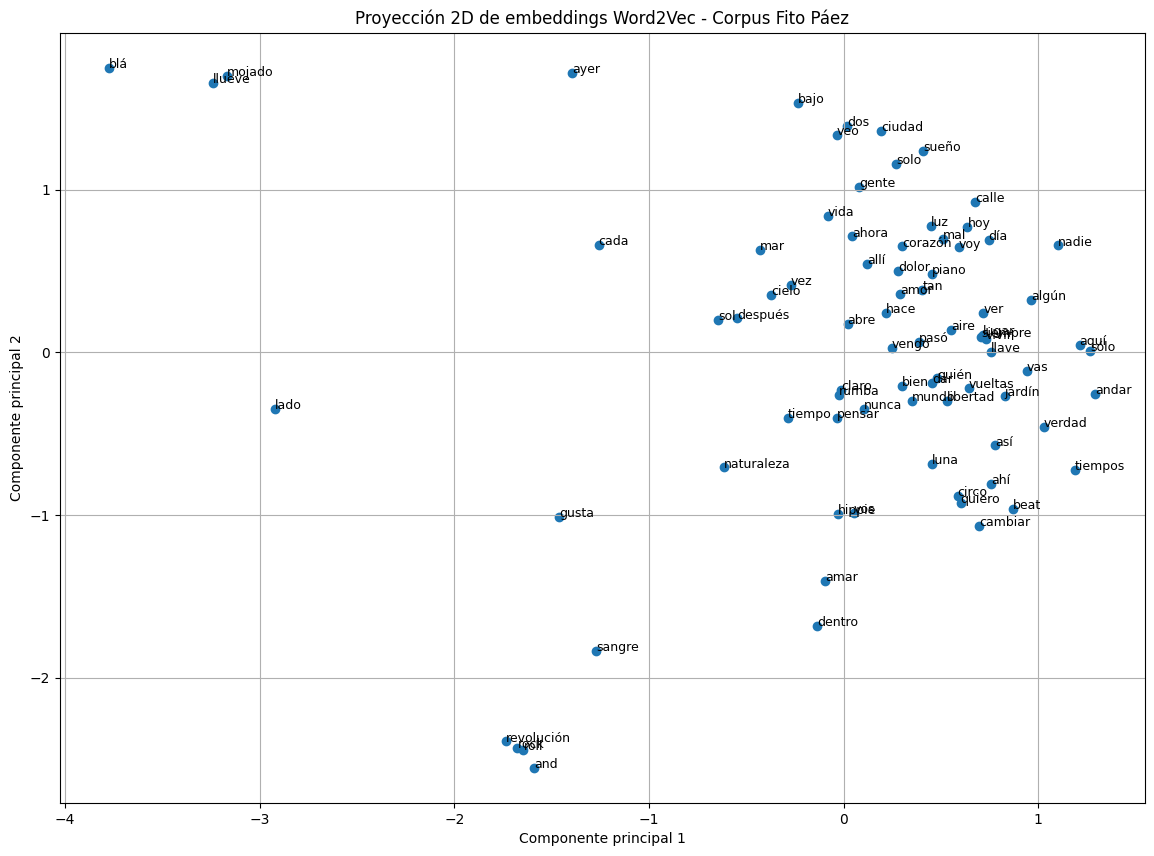

In [39]:
# Visualización 2D de embeddings

plt.figure(figsize=(14, 10))
plt.scatter(df_embeddings["x"], df_embeddings["y"])

for i, row in df_embeddings.iterrows():
    plt.annotate(row["word"], (row["x"], row["y"]), fontsize=9)

plt.title("Proyección 2D de embeddings Word2Vec - Corpus Fito Páez")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.grid(True)
plt.show()

#### Interpretación de la proyección 2D

En la proyección 2D se observan pequeños grupos de palabras cercanas entre sí. Esta cercanía indica que el modelo las ubicó en zonas parecidas del espacio vectorial, probablemente porque aparecen en contextos similares dentro de las canciones.

Un primer grupo está formado por palabras asociadas a emociones y vínculos, como `amor`, `dolor`, `corazón` y otras palabras cercanas en el gráfico. Esto se relaciona con una temática frecuente en el corpus: sentimientos, relaciones afectivas y experiencias personales. Llamativamente (o no) la palabra `piano` está muy cercana a estas emociones, algo que tiene mucha lógica, ya que es el medio a través del cual Fito se expresa.

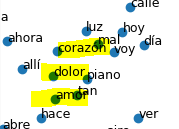

En otra zona del gráfico aparecen cercanas palabras como `mar`, `cielo` y `sol`. Este grupo puede interpretarse como un conjunto de imágenes asociadas a la naturaleza y al paisaje. En las letras, estas palabras suelen funcionar como recursos poéticos para expresar estados de ánimo, sensaciones o momentos importantes dentro de las canciones.

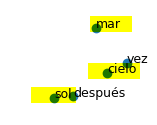


En otro sector del gráfico aparecen cercanas palabras como `tiempo`, `pensar`, `mundo`, `libertad` y `bien`. Este grupo puede relacionarse con ideas de reflexión, búsqueda personal y formas de mirar la vida.

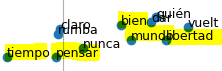

Es importante tener en cuenta que la reducción a dos dimensiones simplifica mucho la información original de los embeddings. Por eso, la cercanía entre palabras debe interpretarse como una aproximación visual. Además, como el corpus es relativamente chico y pertenece a un solo artista, algunos agrupamientos pueden depender de frases o canciones específicas.

## Conclusiones

Se logró entrenar un modelo Word2Vec a partir de un corpus propio formado por letras de canciones de Fito Páez. A partir del modelo se obtuvieron vectores de palabras que permitieron analizar similitudes entre términos frecuentes y visualizar algunas relaciones dentro del vocabulario del corpus.

Los resultados muestran que varias palabras aparecen cercanas por compartir contextos similares en las canciones. En algunos casos se observan asociaciones vinculadas con emociones, recuerdos, imágenes poéticas, lugares o ideas más abstractas como el tiempo, el mundo y la libertad. Esto resulta coherente con el estilo de las letras analizadas.

También se observaron asociaciones menos esperadas, que no necesariamente indican sinonimia, sino cercanía por uso contextual. Esto se debe en parte a que el corpus es relativamente pequeño y pertenece a un solo artista, por lo que algunas relaciones pueden estar influidas por frases, repeticiones o canciones específicas.

La proyección en dos dimensiones permitió explorar visualmente algunos agrupamientos, aunque debe interpretarse con cuidado porque reduce información del espacio vectorial original. Aun así, el experimento permitió comprobar cómo Word2Vec puede aprender representaciones de palabras a partir de un corpus específico y reflejar parte de sus temas y formas de expresión.